In [14]:
##### Figure 1: country and pixel-scale intensities

from pathlib import Path
import pandas as pd
import geopandas as gpd
import rioxarray as rio
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.patches import Rectangle
import matplotlib.gridspec as gridspec
import string

In [9]:
##### Load data

# Get the current working directory
cd = Path.cwd().parent.parent

# pixel data
capital_intensity = rio.open_rasterio(f"{cd}/Results/Raster_model/capital_intensity_USD_per_tonne.tif")
labor_intensity = rio.open_rasterio(f"{cd}/Results/Raster_model/labor_intensity_jobs_per_tonne.tif")

# national data
country_intensities = pd.read_csv(f"{cd}/Data/Clean/Intensities/country_intensities.csv")
country_boundaries = gpd.read_file(f"{cd}/Data/Clean/Geographies/country_geo.shp")

has_data = pd.read_csv(f'{cd}/Data/Correspondence_tables/has_data.csv')

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/FINAL_FIGURES"

In [10]:
##### Data prep

# reproject to mapping CRS
target_crs = "+proj=eck4 +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"

capital_intensity = capital_intensity.rio.reproject(target_crs)
labor_intensity = labor_intensity.rio.reproject_match(capital_intensity)

country_boundaries = country_boundaries.to_crs(capital_intensity.rio.crs)

# add geo to country intensities
country_boundaries = country_boundaries.merge(country_intensities, on='ISO3', how='left')

# Identify no data countries
country_boundaries = country_boundaries.merge(has_data, on='SHP_code', how='left')
country_boundaries['has_capital_data'] = country_boundaries['has_capital_data'].fillna(0)
country_boundaries['has_labor_data'] = country_boundaries['has_labor_data'].fillna(0)

/var/folders/48/ky2jtbmj31bfj15cr5gq480w0000gn/T/ipykernel_45811/2701183255.py:99: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_ax.boxplot(
/var/folders/48/ky2jtbmj31bfj15cr5gq480w0000gn/T/ipykernel_45811/2701183255.py:99: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_ax.boxplot(


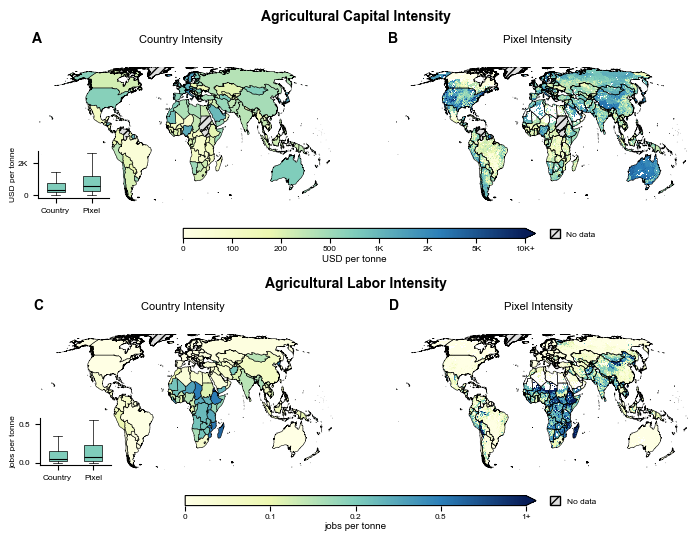

In [17]:
##### FIG 1: INTENSITIES SIDE-BY-SIDE

# set style
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# helper functions
def make_cmap():
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "ylgnbu", ["#ffffe5", "#edf8b1", "#7fcdbb", "#2c7fb8", "#081d58"]
    )
    cmap.set_over("#081d58")
    return cmap

def make_norm(bounds):
    positions = np.linspace(0, 1, len(bounds))

    def forward(x, bounds=bounds, positions=positions):
        return np.interp(x, bounds, positions)

    def inverse(x, bounds=bounds, positions=positions):
        return np.interp(x, positions, bounds)

    return mcolors.FuncNorm((forward, inverse), vmin=bounds[0], vmax=bounds[-1])

def plot_intensity_stacked(specs, country_gdf, out_path, missing_color="#e0e0e0"):
    minx, miny, maxx, maxy = country_gdf.total_bounds
    data_w = maxx - minx
    data_h = maxy - miny

    fig_width = 7.2
    panel_width = fig_width / 2
    map_height = panel_width * (data_h / data_w)
    fig_height = (map_height + 1.0) * len(specs)

    fig = plt.figure(figsize=(fig_width, fig_height), layout="constrained")
    subfigs = fig.subfigures(nrows=len(specs), ncols=1)
    if len(specs) == 1:
        subfigs = [subfigs]

    panel_letters = ["A", "B", "C", "D", "E", "F"]
    letter_idx = 0

    for spec, subfig in zip(specs, subfigs):
        value_col = spec["value_col"]
        coverage_col = spec["coverage_col"]
        bounds = spec["bounds"]
        labels = spec["labels"]
        cbar_label = spec["cbar_label"]
        raster = spec["raster"]
        value_plot = raster.squeeze()
        cmap = make_cmap()
        norm = make_norm(bounds)

        subfig.suptitle(spec["row_title"], fontsize=10, fontweight="bold")

        ax0, ax1 = subfig.subplots(1, 2)

        # --- Panel 1: country-level choropleth ---
        country_has_data = country_gdf[country_gdf[coverage_col] == 1]
        country_no_data = country_gdf[country_gdf[coverage_col] == 0]
        country_no_data.plot(ax=ax0, facecolor=missing_color, edgecolor="black", linewidth=0.4, hatch="////", zorder=1)
        country_has_data.plot(ax=ax0, column=value_col, cmap=cmap, norm=norm,
                               edgecolor="black", linewidth=0.4, zorder=2)
        ax0.set_xlim(minx, maxx); ax0.set_ylim(miny, maxy)
        ax0.set_aspect("equal"); ax0.set_axis_off()

        # --- Panel 2: pixel intensity ---
        country_gdf[country_gdf[coverage_col] == 0].plot(
            ax=ax1, facecolor=missing_color, edgecolor="black", linewidth=0.4, hatch="////", zorder=1
        )
        value_plot.plot(ax=ax1, cmap=cmap, norm=norm, add_colorbar=False, add_labels=False, zorder=2)
        country_gdf.plot(ax=ax1, facecolor="none", edgecolor="black", linewidth=0.4, zorder=3)
        ax1.set_xlim(minx, maxx); ax1.set_ylim(miny, maxy)
        ax1.set_aspect("equal"); ax1.set_axis_off()

        ax0.set_title(panel_letters[letter_idx], loc="left", fontsize=10, fontweight="bold")
        ax0.set_title("Country Intensity", loc="center", fontsize=8)
        letter_idx += 1
        ax1.set_title(panel_letters[letter_idx], loc="left", fontsize=10, fontweight="bold")
        ax1.set_title("Pixel Intensity", loc="center", fontsize=8)
        letter_idx += 1

        # --- Boxplot inset ---
        country_vals = country_has_data[value_col].dropna().values
        pixel_vals = np.asarray(value_plot.values).ravel()
        pixel_vals = pixel_vals[np.isfinite(pixel_vals)]
        pixel_vals = pixel_vals[pixel_vals > 0]

        box_ax = ax0.inset_axes([0.02, 0.04, 0.24, 0.34], transform=ax0.transAxes)
        box_ax.boxplot(
            [country_vals, pixel_vals], labels=["Country", "Pixel"], widths=0.5,
            showfliers=False, patch_artist=True,
            boxprops=dict(facecolor="#7fcdbb", edgecolor="black", linewidth=0.5),
            medianprops=dict(color="black", linewidth=0.8),
            whiskerprops=dict(linewidth=0.5), capprops=dict(linewidth=0.5),
        )
        box_ax.set_facecolor("white"); box_ax.patch.set_alpha(0.85)
        box_ax.tick_params(labelsize=6)
        box_ax.set_ylabel(cbar_label, fontsize=6, labelpad=1)
        for spine in ["top", "right"]:
            box_ax.spines[spine].set_visible(False)

        if max(bounds) >= 1000:
            def k_formatter(x, pos):
                return f'{x/1000:.0f}K' if x >= 1000 else f'{x:.0f}'
            box_ax.yaxis.set_major_formatter(mticker.FuncFormatter(k_formatter))

        # --- Shared colorbar
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        cbar = subfig.colorbar(sm, ax=[ax0, ax1], location="bottom",
                                shrink=0.5, aspect=35, pad=0.08, extend="max", extendfrac=0.03)
        cbar.set_label(cbar_label, fontsize=7, labelpad=2)
        cbar.ax.tick_params(labelsize=6, pad=2)
        cbar.set_ticks(bounds)
        cbar.set_ticklabels(labels)

        no_data_patch = mpatches.Patch(facecolor=missing_color, edgecolor="black",
                                        hatch="///", label="No data")
        cbar.ax.legend(handles=[no_data_patch], loc="center left",
                        bbox_to_anchor=(1.05, 0.5), frameon=False, fontsize=6,
                        handlelength=1.2, handleheight=1.2)

    fig.savefig(out_path, dpi=300, format="tiff")
    plt.show()

# set specs
specs = [
    dict(
        raster=capital_intensity, value_col="capital_intensity_USD_per_tonne",
        coverage_col="has_capital_data",
        bounds=[0, 100, 200, 500, 1000, 2000, 5000, 10000],
        labels=['0', '100', '200', '500', '1K', '2K', '5K', '10K+'],
        row_title="Agricultural Capital Intensity", cbar_label="USD per tonne",
    ),
    dict(
        raster=labor_intensity, value_col="labor_intensity_jobs_per_tonne",
        coverage_col="has_labor_data",
        bounds=[0, 0.1, 0.2, 0.5, 1],
        labels=['0', '0.1', '0.2', '0.5', '1+'],
        row_title="Agricultural Labor Intensity", cbar_label="jobs per tonne",
    ),
]

# plot & save
plot_intensity_stacked(specs, country_boundaries, out_path=f"{fd}/FIG_1_intensities.tiff")